In [1]:
import pandas as pd

In [2]:
pp = pd.read_csv(r"C:\Users\YASH\OneDrive\Desktop\Classes Study Material\Streamlit Projects\House_Price_Prediction\train.csv")
pp.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


In [3]:
pp.shape

(1460, 81)

In [5]:
# pp.info()

In [6]:
pp['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

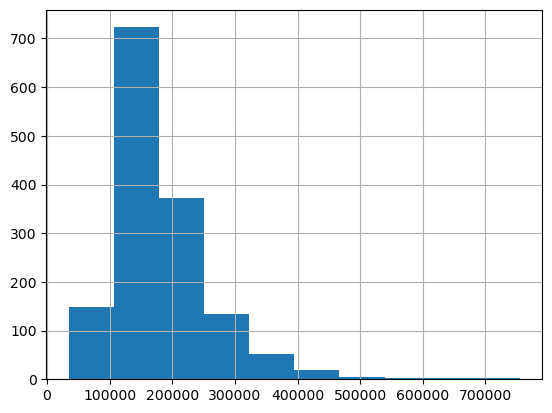

In [7]:
pp['SalePrice'].hist()

In [8]:
pp.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [9]:
pp.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [10]:
pp.isnull().sum().sum()

np.int64(7829)

In [11]:
missing = pp.isnull().sum()
missing = missing[missing > 0]

missing_percent = (missing / len(pp)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

missing_df.head(20)

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [12]:
pp.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [13]:
pp.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [14]:
X = pp.drop("SalePrice", axis=1)
Y = pp["SalePrice"]

In [15]:
print(X.shape)
print(Y.shape)

(1460, 80)
(1460,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=12345)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 37
Categorical Columns: 43


In [18]:
# creating preprocessing pipeline
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median'))])

In [19]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))])

In [20]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)])

In [21]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [23]:
lr_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
Y_pred = lr_model.predict(X_test)

In [25]:
from sklearn.metrics import *

In [26]:
import numpy as np

In [27]:
mae = mean_absolute_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 17934.12613532899
RMSE: 30239.81844183276
R² Score: 0.779491516039184


<h3>DT model</h3>

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=12345))])

In [30]:
dt_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
Y_pred_dt = dt_model.predict(X_test)

In [33]:
mae_dt = mean_absolute_error(Y_test, Y_pred_dt)
rmse_dt = root_mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

MAE: 29442.90068493151
RMSE: 45604.33057561529
R² Score: 0.4984905568991189


<h3>Rf model</h3>

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:
rf_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
Y_pred_rf = rf_model.predict(X_test)

In [37]:
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
r2_rf = r2_score(Y_test, Y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 16422.81633561644
RMSE: 29253.810698229132
R² Score: 0.7936369974486905


<h3>Gradient Boosting model</h3>

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [39]:
gb_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
Y_pred_gb = gb_model.predict(X_test)

In [41]:
mae_gb = mean_absolute_error(Y_test, Y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(Y_test, Y_pred_gb))
r2_gb = r2_score(Y_test, Y_pred_gb)

print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

MAE: 15985.994802676403
RMSE: 32028.86119392844
R² Score: 0.7526283423282387


In [42]:
# Model_comparision
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, mae_dt, mae_rf, mae_gb],
    "RMSE": [rmse, rmse_dt, rmse_rf, rmse_gb],
    "R2": [r2, r2_dt, r2_rf, r2_gb]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,16422.816336,29253.810698,0.793637
0,Linear Regression,17934.126135,30239.818442,0.779492
3,Gradient Boosting,15985.994803,32028.861194,0.752628
1,Decision Tree,29442.900685,45604.330576,0.498491


<h3>Pickling</h3>

In [43]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [45]:
# joblib.dump() is a form of pickling (serialization).

In [46]:
pwd

'C:\\Users\\YASH'

In [47]:
import sklearn
import pandas
import numpy
import joblib

print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.7.2
pandas: 2.3.3
numpy: 2.5.3
joblib: 1.5.2


In [48]:
import sys

print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
